<a href="https://colab.research.google.com/github/MrStranger812/MovieLens-CLI-DM/blob/NotebookGCPP/Notebooks/02_Regression_MovieLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MovieLens 20M - GPU-Accelerated Regression Models

This notebook implements various gradient descent algorithms for rating prediction using GPU acceleration with CuPy and the NVIDIA L4 GPU.

## Table of Contents
1. Environment Setup & GPU Configuration
2. Data Loading & Exploration
3. Feature Engineering for Regression
4. GPU-Accelerated Gradient Descent Implementation
5. Model Training & Comparison
6. Hyperparameter Tuning
7. Results Analysis & Visualization
8. Model Persistence & Deployment

In [ ]:
# Cell 1: Environment setup and GPU verification
import os
import sys
import gc
import psutil
import torch
import pandas as pd
import numpy as np
import pickle
import gzip
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich.progress import Progress, SpinnerColumn, TextColumn
from tqdm.notebook import tqdm

# Set up console for pretty printing
console = Console()

# Check GPU availability
def check_gpu_setup():
    """Comprehensive GPU setup check"""
    console.print(Panel.fit("[bold blue]🔧 GPU Environment Check[/bold blue]", border_style="blue"))

    # Check PyTorch GPU
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
        console.print(f"[green]✅ PyTorch GPU: {gpu_name} ({gpu_memory:.1f} GB)[/green]")

        # Check CUDA version
        console.print(f"[green]✅ CUDA Version: {torch.version.cuda}[/green]")
    else:
        console.print("[red]❌ PyTorch GPU not available[/red]")

    # Check system resources
    ram_gb = psutil.virtual_memory().total / 1024**3
    console.print(f"[blue]💾 System RAM: {ram_gb:.1f} GB[/blue]")
    console.print(f"[blue]🧮 CPU Cores: {psutil.cpu_count()}[/blue]")

    return torch.cuda.is_available()

gpu_available = check_gpu_setup()

# Define project paths
BASE_DIR = Path("/content/drive/MyDrive/Movielens")
DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

console.print(f"[green]✅ Project directory: {BASE_DIR}[/green]")

╭──────────────────────────╮
│ 🔧 GPU Environment Check │
╰──────────────────────────╯

✅ PyTorch GPU: NVIDIA L4 (22.2 GB)

✅ CUDA Version: 12.4

💾 System RAM: 53.0 GB

🧮 CPU Cores: 12

✅ Project directory: /content/drive/MyDrive/Movielens

In [ ]:
# Cell 2: Install CuPy for GPU acceleration
try:
    import cupy as cp
    GPU_CUPY_AVAILABLE = True
    console.print("[green]✅ CuPy already installed[/green]")
except ImportError:
    console.print("[yellow]Installing CuPy for GPU acceleration...[/yellow]")
    !pip install cupy-cuda12x
    import cupy as cp
    GPU_CUPY_AVAILABLE = True
    console.print("[green]✅ CuPy installed successfully[/green]")

# Verify CuPy GPU access
if GPU_CUPY_AVAILABLE:
    try:
        # Test CuPy GPU operations
        test_array = cp.array([1, 2, 3])
        result = cp.sum(test_array)
        console.print(f"[green]✅ CuPy GPU test successful: sum = {result}[/green]")

        # Get GPU memory info
        mempool = cp.get_default_memory_pool()
        console.print(f"[blue]GPU Memory Pool: {mempool.used_bytes() / 1024**2:.1f} MB used[/blue]")
    except Exception as e:
        console.print(f"[red]❌ CuPy GPU test failed: {e}[/red]")
        GPU_CUPY_AVAILABLE = False

✅ CuPy already installed

✅ CuPy GPU test successful: sum = 6

GPU Memory Pool: 0.0 MB used

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 3: Load preprocessed data from previous notebook
def load_preprocessed_data():
    """Load the preprocessed data from notebook 01"""
    console.print("[cyan]Loading preprocessed data...[/cyan]")

    try:
        # Load feature matrices
        user_features = pd.read_parquet(PROCESSED_DATA_DIR / "user_features.parquet")
        movie_features = pd.read_parquet(PROCESSED_DATA_DIR / "movie_features.parquet")

        # Load sparse matrix
        from scipy.sparse import load_npz
        user_item_matrix = load_npz(PROCESSED_DATA_DIR / "user_item_matrix.npz")

        # Load mappings
        with open(PROCESSED_DATA_DIR / "mappings.pkl", 'rb') as f:
            mappings = pickle.load(f)

        console.print(f"[green]✅ Loaded user features: {user_features.shape}[/green]")
        console.print(f"[green]✅ Loaded movie features: {movie_features.shape}[/green]")
        console.print(f"[green]✅ Loaded user-item matrix: {user_item_matrix.shape}[/green]")

        return {
            'user_features': user_features,
            'movie_features': movie_features,
            'user_item_matrix': user_item_matrix,
            'user_mapping': mappings['user_mapping'],
            'movie_mapping': mappings['movie_mapping']
        }
    except Exception as e:
        console.print(f"[red]❌ Error loading data: {e}[/red]")
        console.print("[yellow]Please run notebook 01_Data_Preprocessing.ipynb first[/yellow]")
        raise

# Load the data
data = load_preprocessed_data()

# Display data statistics
table = Table(title="📊 Loaded Data Summary")
table.add_column("Component", style="cyan")
table.add_column("Shape/Count", style="yellow")
table.add_column("Memory Usage", style="green")

table.add_row("User Features",
              f"{data['user_features'].shape[0]:,} users × {data['user_features'].shape[1]} features",
              f"{data['user_features'].memory_usage().sum() / 1024**2:.1f} MB")
table.add_row("Movie Features",
              f"{data['movie_features'].shape[0]:,} movies × {data['movie_features'].shape[1]} features",
              f"{data['movie_features'].memory_usage().sum() / 1024**2:.1f} MB")
table.add_row("User-Item Matrix",
              f"{data['user_item_matrix'].shape[0]:,} × {data['user_item_matrix'].shape[1]:,}",
              f"{data['user_item_matrix'].data.nbytes / 1024**2:.1f} MB")

console.print(table)

Loading preprocessed data...

✅ Loaded user features: (138493, 5)

✅ Loaded movie features: (27278, 9)

✅ Loaded user-item matrix: (138493, 26744)

                     📊 Loaded Data Summary                     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Component        ┃ Shape/Count                ┃ Memory Usage ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ User Features    │ 138,493 users × 5 features │ 4.8 MB       │
│ Movie Features   │ 27,278 movies × 9 features │ 1.9 MB       │
│ User-Item Matrix │ 138,493 × 26,744           │ 152.6 MB     │
└──────────────────┴────────────────────────────┴──────────────┘

Creating regression dataset...

✅ Created dataset with 20,000,263 ratings

Merging with features...

✅ Final dataset: 20,000,263 samples × 14 features

  • User features: 5

...

Target Variable Statistics:

Mean rating: 3.526

Std rating: 1.052

Min rating: 0.5

Max rating: 5.0

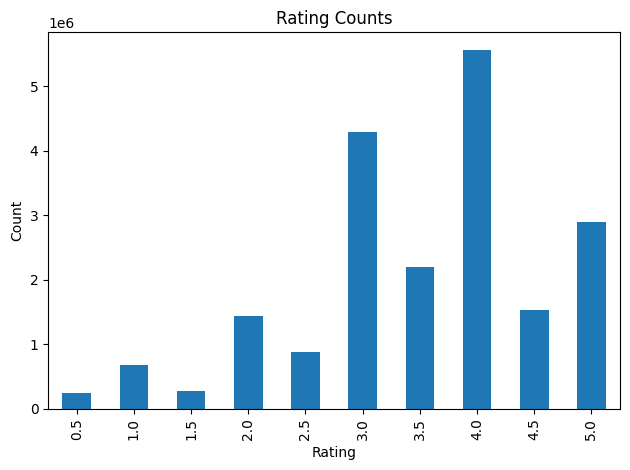

In [ ]:
# Cell 4: Create regression dataset from sparse matrix
def create_regression_dataset(data, sample_size=None, min_rating_count=10):
    """
    Create dataset for regression from user-item matrix
    """
    console.print("[cyan]Creating regression dataset...[/cyan]")

    # Convert sparse matrix to COO format for easy extraction
    user_item_coo = data['user_item_matrix'].tocoo()

    # Create DataFrame with ratings
    ratings_df = pd.DataFrame({
        'user_idx': user_item_coo.row,
        'movie_idx': user_item_coo.col,
        'rating': user_item_coo.data
    })

    # Sample if requested
    if sample_size and sample_size < len(ratings_df):
        console.print(f"[yellow]Sampling {sample_size:,} ratings...[/yellow]")
        ratings_df = ratings_df.sample(n=sample_size, random_state=42)

    console.print(f"[green]✅ Created dataset with {len(ratings_df):,} ratings[/green]")

    # Merge with user and movie features
    console.print("[cyan]Merging with features...[/cyan]")

    # Reset index for merging
    user_features = data['user_features'].reset_index()
    movie_features = data['movie_features'].reset_index()

    # Map indices back to IDs for merging
    reverse_user_map = {v: k for k, v in data['user_mapping'].items()}
    reverse_movie_map = {v: k for k, v in data['movie_mapping'].items()}

    ratings_df['userId'] = ratings_df['user_idx'].map(reverse_user_map)
    ratings_df['movieId'] = ratings_df['movie_idx'].map(reverse_movie_map)

    # Merge features
    dataset = ratings_df.merge(user_features, on='userId', how='left')
    dataset = dataset.merge(movie_features, on='movieId', how='left', suffixes=('_user', '_movie'))

    # Drop ID columns and keep only features
    feature_cols = [col for col in dataset.columns
                   if col not in ['userId', 'movieId', 'user_idx', 'movie_idx', 'rating']]

    X = dataset[feature_cols]
    y = dataset['rating']

    console.print(f"[green]✅ Final dataset: {X.shape[0]:,} samples × {X.shape[1]} features[/green]")

    # Print feature groups
    user_feat_cols = [col for col in feature_cols if '_user' in col or col in user_features.columns]
    movie_feat_cols = [col for col in feature_cols if '_movie' in col or col in movie_features.columns]

    console.print(f"[blue]  • User features: {len(user_feat_cols)}[/blue]")
    console.print(f"[blue]  • Movie features: {len(movie_feat_cols)}[/blue]")

    return X, y, feature_cols

# Create regression dataset
# Start with a sample for initial testing
X, y, feature_names = create_regression_dataset(data, sample_size=None)

# Display basic statistics
console.print("\n[cyan]Target Variable Statistics:[/cyan]")
console.print(f"Mean rating: {y.mean():.3f}")
console.print(f"Std rating: {y.std():.3f}")
console.print(f"Min rating: {y.min()}")
console.print(f"Max rating: {y.max()}")



y.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Counts')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Split data and preprocess for GPU
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_data_for_training(X, y, test_size=0.2, val_size=0.1):
    """Prepare data with train/val/test split and scaling"""
    console.print("[cyan]Preparing data for training...[/cyan]")

    # First split: train+val vs test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y.astype(int)
    )

    # Second split: train vs val
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp.astype(int)
    )

    numeric_features = X_train.select_dtypes(include=['int64', 'float64', np.number]).columns.tolist()
    console.print(f"[yellow]Identified {len(numeric_features)} numeric features to scale.[/yellow]")

    # Scale features
    scaler = StandardScaler()

    scaler.fit(X_train[numeric_features])

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

    # Fit on training data and transform all sets
    X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
    X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
    X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])


    console.print(f"[green]✅ Train set: {len(X_train_scaled):,} samples[/green]")
    console.print(f"[green]✅ Val set: {len(X_val_scaled):,} samples[/green]")
    console.print(f"[green]✅ Test set: {len(X_test_scaled):,} samples[/green]")

    return {
        'X_train': X_train_scaled,
        'X_val': X_val_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'scaler': scaler
    }

# Prepare the data
data_splits = prepare_data_for_training(X, y)

# Verify data distribution across splits
splits_table = Table(title="Data Split Statistics")
splits_table.add_column("Split", style="cyan")
splits_table.add_column("Samples", style="yellow")
splits_table.add_column("Mean Rating", style="green")
splits_table.add_column("Std Rating", style="blue")

for split_name in ['train', 'val', 'test']:
    y_split = data_splits[f'y_{split_name}']
    splits_table.add_row(
        split_name.capitalize(),
        f"{len(y_split):,}",
        f"{y_split.mean():.3f}",
        f"{y_split.std():.3f}"
    )

console.print(splits_table)

Preparing data for training...

Identified 11 numeric features to scale.

✅ Train set: 14,000,183 samples

✅ Val set: 2,000,027 samples

✅ Test set: 4,000,053 samples

              Data Split Statistics              
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Split ┃ Samples    ┃ Mean Rating ┃ Std Rating ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Train │ 14,000,183 │ 3.526       │ 1.052      │
│ Val   │ 2,000,027  │ 3.525       │ 1.052      │
│ Test  │ 4,000,053  │ 3.525       │ 1.052      │
└───────┴────────────┴─────────────┴────────────┘

In [ ]:
# Cell 7: Clean GPU Gradient Descent Implementation
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# GPU computation with fallback
try:
    import cupy as cp
    GPU_AVAILABLE = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False

class GPUGradientDescent:
    """Clean GPU-accelerated gradient descent for regression"""

    def __init__(self, learning_rate=0.001, n_iterations=100, method="mini_batch",
                 batch_size=512, momentum=0.9, regularization="l2", lambda_reg=0.01,
                 early_stopping=True, patience=10, verbose=False):

        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.method = method
        self.batch_size = batch_size
        self.momentum = momentum
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.early_stopping = early_stopping
        self.patience = patience
        self.verbose = verbose

        # Model parameters
        self.weights = None
        self.bias = None
        self.vw = None
        self.vb = 0.0
        self.scaler = None
        self.is_fitted = False

        # Training history
        self.loss_history = []
        self.val_loss_history = []
        self.best_weights = None
        self.best_bias = None
        self.best_val_loss = float('inf')
        self.patience_counter = 0

    def _preprocess_data(self, X, y=None, fit_scaler=True):
        """Clean and scale data"""
        # Keep only numeric columns
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        X_clean = X[numeric_cols].fillna(X[numeric_cols].median())

        # Scale features
        if fit_scaler:
            self.scaler = StandardScaler()
            X_scaled = self.scaler.fit_transform(X_clean)
        else:
            X_scaled = self.scaler.transform(X_clean)

        # Convert to GPU arrays
        X_gpu = cp.asarray(X_scaled, dtype=cp.float32)
        y_gpu = cp.asarray(y, dtype=cp.float32) if y is not None else None

        return X_gpu, y_gpu

    def _initialize_weights(self, n_features):
        """Initialize weights and momentum"""
        limit = cp.sqrt(6.0 / n_features)
        self.weights = cp.random.uniform(-limit, limit, n_features).astype(cp.float32)
        self.vw = cp.zeros(n_features, dtype=cp.float32)
        self.bias = 0.0
        self.vb = 0.0

    def _compute_loss(self, y_true, y_pred):
        """Compute MSE loss with regularization"""
        mse = cp.mean((y_pred - y_true) ** 2)

        if self.regularization == 'l2':
            reg = self.lambda_reg * cp.sum(self.weights ** 2)
        elif self.regularization == 'l1':
            reg = self.lambda_reg * cp.sum(cp.abs(self.weights))
        else:
            reg = 0

        return mse + reg

    def _compute_gradients(self, X, y, predictions):
        """Compute gradients"""
        n_samples = X.shape[0]
        residuals = predictions - y

        dw = (2.0 / n_samples) * (X.T @ residuals)
        db = (2.0 / n_samples) * cp.sum(residuals)

        # Add regularization
        if self.regularization == 'l2':
            dw += 2 * self.lambda_reg * self.weights
        elif self.regularization == 'l1':
            dw += self.lambda_reg * cp.sign(self.weights)

        # Clip gradients
        grad_norm = cp.linalg.norm(dw)
        if grad_norm > 10.0:
            dw = dw * (10.0 / grad_norm)

        return dw, db

    def _update_parameters(self, dw, db):
        """Update parameters with momentum"""
        self.vw = self.momentum * self.vw + self.learning_rate * dw
        self.vb = self.momentum * self.vb + self.learning_rate * db

        self.weights -= self.vw
        self.bias -= self.vb

    def _train_epoch(self, X, y, X_val=None, y_val=None):
        """Train one epoch based on method"""
        n_samples = X.shape[0]

        if self.method == 'batch':
            # Full batch
            predictions = X @ self.weights + self.bias
            dw, db = self._compute_gradients(X, y, predictions)
            self._update_parameters(dw, db)
            train_loss = self._compute_loss(y, predictions)

        elif self.method == 'mini_batch':
            # Mini-batch
            indices = cp.random.permutation(n_samples)
            X_shuffled, y_shuffled = X[indices], y[indices]
            epoch_loss = 0
            n_batches = 0

            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                X_batch, y_batch = X_shuffled[start:end], y_shuffled[start:end]

                predictions = X_batch @ self.weights + self.bias
                dw, db = self._compute_gradients(X_batch, y_batch, predictions)
                self._update_parameters(dw, db)

                epoch_loss += self._compute_loss(y_batch, predictions)
                n_batches += 1

            train_loss = epoch_loss / n_batches

        else:  # sgd
            # Small mini-batches for efficiency
            batch_size = min(32, n_samples // 100)
            indices = cp.random.permutation(n_samples)
            X_shuffled, y_shuffled = X[indices], y[indices]
            epoch_loss = 0
            n_batches = 0

            for start in range(0, n_samples, batch_size):
                end = min(start + batch_size, n_samples)
                X_batch, y_batch = X_shuffled[start:end], y_shuffled[start:end]

                predictions = X_batch @ self.weights + self.bias
                dw, db = self._compute_gradients(X_batch, y_batch, predictions)
                self._update_parameters(dw, db)

                epoch_loss += self._compute_loss(y_batch, predictions)
                n_batches += 1

            train_loss = epoch_loss / n_batches

        # Validation loss
        val_loss = None
        if X_val is not None:
            val_pred = X_val @ self.weights + self.bias
            val_loss = self._compute_loss(y_val, val_pred)

        return train_loss, val_loss

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """Train the model"""
        # Preprocess data
        X_train_gpu, y_train_gpu = self._preprocess_data(X_train, y_train, fit_scaler=True)
        X_val_gpu, y_val_gpu = None, None
        if X_val is not None:
            X_val_gpu, y_val_gpu = self._preprocess_data(X_val, y_val, fit_scaler=False)

        # Initialize
        self._initialize_weights(X_train_gpu.shape[1])

        # Training loop
        for iteration in range(self.n_iterations):
            train_loss, val_loss = self._train_epoch(X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu)

            self.loss_history.append(cp.asnumpy(train_loss))
            if val_loss is not None:
                self.val_loss_history.append(cp.asnumpy(val_loss))

                # Early stopping
                if self.early_stopping:
                    if val_loss < self.best_val_loss:
                        self.best_val_loss = val_loss
                        self.best_weights = self.weights.copy()
                        self.best_bias = self.bias
                        self.patience_counter = 0
                    else:
                        self.patience_counter += 1
                        if self.patience_counter >= self.patience:
                            break

            if self.verbose and iteration % 10 == 0:
                msg = f"Iter {iteration}: Loss {train_loss:.4f}"
                if val_loss is not None:
                    msg += f", Val {val_loss:.4f}"
                print(msg)

        # Restore best weights
        if self.early_stopping and self.best_weights is not None:
            self.weights = self.best_weights
            self.bias = self.best_bias

        self.is_fitted = True
        return self

    def predict(self, X):
        """Make predictions"""
        X_gpu, _ = self._preprocess_data(X, fit_scaler=False)
        predictions = X_gpu @ self.weights + self.bias
        return cp.asnumpy(predictions)

    def score(self, X, y):
        """R² score"""
        predictions = self.predict(X)
        return r2_score(y, predictions)

print("✅ Clean GPU Gradient Descent loaded")

✅ Clean GPU Gradient Descent loaded


Train: 40,000, Val: 10,000
Features: 14, Target range: [0.5, 5.0]

Training Mini-Batch...
  RMSE: 0.8692, R²: 0.3223, Time: 2.0s

Training Batch...
  RMSE: 3.4117, R²: -9.4423, Time: 0.1s

Training SGD...
  RMSE: 0.8688, R²: 0.3229, Time: 15.0s

Method       RMSE     R²       Time     Iters   
--------------------------------------------------
Mini-Batch   0.8692   0.3223   2.0      30      
Batch        3.4117   -9.4423  0.1      20      
SGD          0.8688   0.3229   15.0     15      

Best: SGD (RMSE: 0.8688)


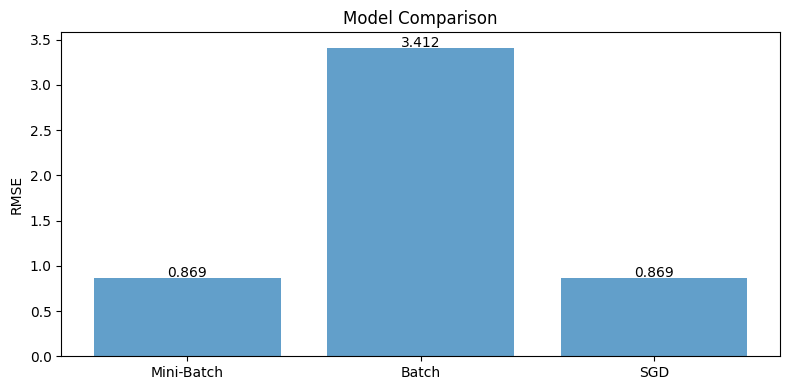

In [ ]:
# Cell 8: Simple Test
# Sample data
X_sample = data_splits['X_train'].iloc[:50000]
y_sample = data_splits['y_train'].iloc[:50000]

X_train, X_val, y_train, y_val = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}")
print(f"Features: {X_train.shape[1]}, Target range: [{y_train.min():.1f}, {y_train.max():.1f}]")

# Test models
configs = {
    'Mini-Batch': {'method': 'mini_batch', 'learning_rate': 0.001, 'n_iterations': 30},
    'Batch': {'method': 'batch', 'learning_rate': 0.0005, 'n_iterations': 20},
    'SGD': {'method': 'sgd', 'learning_rate': 0.0001, 'n_iterations': 15}
}

results = {}
for name, config in configs.items():
    print(f"\nTraining {name}...")
    start = time.time()

    model = GPUGradientDescent(**config)
    model.fit(X_train, y_train, X_val, y_val)

    predictions = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    results[name] = {
        'rmse': rmse,
        'r2': r2,
        'time': time.time() - start,
        'iterations': len(model.loss_history)
    }

    print(f"  RMSE: {rmse:.4f}, R²: {r2:.4f}, Time: {results[name]['time']:.1f}s")

# Results
print(f"\n{'Method':<12} {'RMSE':<8} {'R²':<8} {'Time':<8} {'Iters':<8}")
print("-" * 50)
for name, res in results.items():
    print(f"{name:<12} {res['rmse']:<8.4f} {res['r2']:<8.4f} {res['time']:<8.1f} {res['iterations']:<8}")

best = min(results.items(), key=lambda x: x[1]['rmse'])
print(f"\nBest: {best[0]} (RMSE: {best[1]['rmse']:.4f})")

# Quick visualization
if len(results) > 0:
    names = list(results.keys())
    rmse_vals = [results[n]['rmse'] for n in names]

    plt.figure(figsize=(8, 4))
    plt.bar(names, rmse_vals, alpha=0.7)
    plt.ylabel('RMSE')
    plt.title('Model Comparison')
    for i, v in enumerate(rmse_vals):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
    plt.tight_layout()
    plt.show()

🚀 Starting complete GPU gradient descent analysis
Training on 100,000 samples
Training mini_batch... RMSE: 0.8638, R²: 0.3251
Training mini_batch_l2... RMSE: 0.8655, R²: 0.3224
Training mini_batch_fast... RMSE: 0.8637, R²: 0.3252
Training batch... RMSE: 2.8136, R²: -6.1600
Training sgd... RMSE: 0.8637, R²: 0.3253
Training sgd_momentum... RMSE: 0.8639, R²: 0.3250

Model           RMSE     R²       MAE      Time     Iters   
-----------------------------------------------------------------
sgd             0.8637   0.3253   0.6637   61.8     25      
mini_batch_fast 0.8637   0.3252   0.6638   2.5      30      
mini_batch      0.8638   0.3251   0.6636   8.0      50      
sgd_momentum    0.8639   0.3250   0.6633   61.8     25      
mini_batch_l2   0.8655   0.3224   0.6678   2.8      17      
batch           2.8136   -6.1600  2.5850   0.3      40      

Best model: sgd (RMSE: 0.8637)


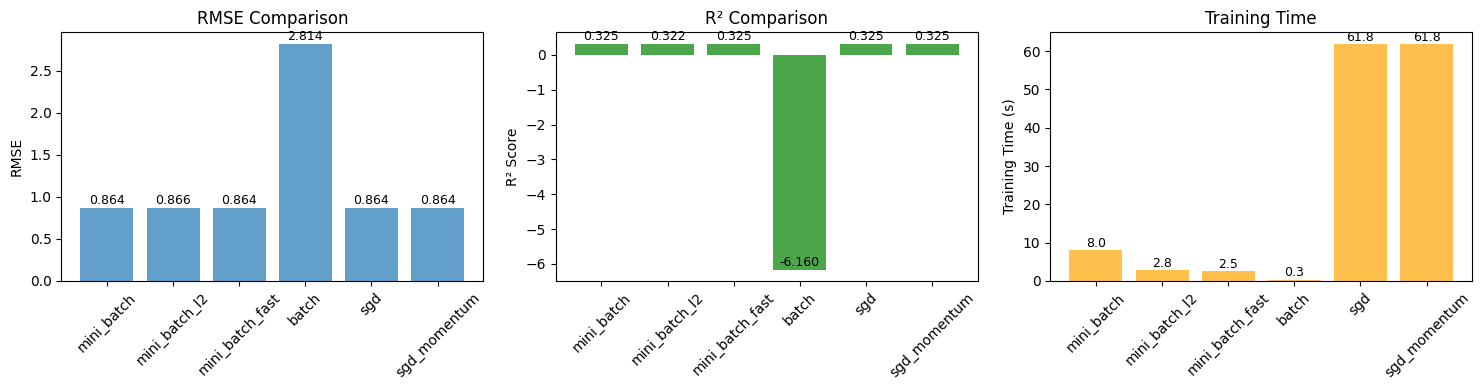


✅ Analysis complete


In [ ]:
# Cell 9: Complete Training Pipeline

def create_models():
    """Create model configurations"""
    return {
        'mini_batch': GPUGradientDescent(method='mini_batch', learning_rate=0.001, n_iterations=50),
        'mini_batch_l2': GPUGradientDescent(method='mini_batch', learning_rate=0.001, n_iterations=50, lambda_reg=0.1),
        'mini_batch_fast': GPUGradientDescent(method='mini_batch', learning_rate=0.002, n_iterations=30, batch_size=1024),
        'batch': GPUGradientDescent(method='batch', learning_rate=0.0005, n_iterations=40),
        'sgd': GPUGradientDescent(method='sgd', learning_rate=0.0001, n_iterations=25),
        'sgd_momentum': GPUGradientDescent(method='sgd', learning_rate=0.0001, n_iterations=25, momentum=0.95)
    }

def evaluate_models(models, X_train, y_train, X_val, y_val, X_test, y_test, sample_size=100000):
    """Train and evaluate all models"""
    # Use sample for faster training
    if len(X_train) > sample_size:
        idx = np.random.choice(len(X_train), sample_size, replace=False)
        X_train_sample = X_train.iloc[idx]
        y_train_sample = y_train.iloc[idx]

        val_size = min(len(X_val), sample_size // 4)
        val_idx = np.random.choice(len(X_val), val_size, replace=False)
        X_val_sample = X_val.iloc[val_idx]
        y_val_sample = y_val.iloc[val_idx]

        test_size = min(len(X_test), sample_size // 2)
        test_idx = np.random.choice(len(X_test), test_size, replace=False)
        X_test_sample = X_test.iloc[test_idx]
        y_test_sample = y_test.iloc[test_idx]
    else:
        X_train_sample, y_train_sample = X_train, y_train
        X_val_sample, y_val_sample = X_val, y_val
        X_test_sample, y_test_sample = X_test, y_test

    print(f"Training on {len(X_train_sample):,} samples")

    results = {}
    for name, model in models.items():
        print(f"Training {name}...", end=" ")
        start = time.time()

        try:
            model.fit(X_train_sample, y_train_sample, X_val_sample, y_val_sample)
            predictions = model.predict(X_test_sample)

            results[name] = {
                'rmse': np.sqrt(mean_squared_error(y_test_sample, predictions)),
                'r2': r2_score(y_test_sample, predictions),
                'mae': mean_absolute_error(y_test_sample, predictions),
                'time': time.time() - start,
                'iterations': len(model.loss_history)
            }
            print(f"RMSE: {results[name]['rmse']:.4f}, R²: {results[name]['r2']:.4f}")

        except Exception as e:
            print(f"Failed: {e}")
            results[name] = {'error': str(e)}

    return results

def display_results(results):
    """Display results table"""
    successful = {k: v for k, v in results.items() if 'error' not in v}

    if not successful:
        print("No successful models")
        return

    print(f"\n{'Model':<15} {'RMSE':<8} {'R²':<8} {'MAE':<8} {'Time':<8} {'Iters':<8}")
    print("-" * 65)

    # Sort by RMSE
    sorted_results = sorted(successful.items(), key=lambda x: x[1]['rmse'])

    for name, res in sorted_results:
        print(f"{name:<15} {res['rmse']:<8.4f} {res['r2']:<8.4f} {res['mae']:<8.4f} {res['time']:<8.1f} {res['iterations']:<8}")

    best = sorted_results[0]
    print(f"\nBest model: {best[0]} (RMSE: {best[1]['rmse']:.4f})")

    return successful

def plot_results(results):
    """Plot model comparison"""
    if not results:
        return

    names = list(results.keys())
    rmse_vals = [results[n]['rmse'] for n in names]
    r2_vals = [results[n]['r2'] for n in names]
    time_vals = [results[n]['time'] for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # RMSE
    bars1 = axes[0].bar(names, rmse_vals, alpha=0.7)
    axes[0].set_ylabel('RMSE')
    axes[0].set_title('RMSE Comparison')
    axes[0].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars1, rmse_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # R²
    bars2 = axes[1].bar(names, r2_vals, alpha=0.7, color='green')
    axes[1].set_ylabel('R² Score')
    axes[1].set_title('R² Comparison')
    axes[1].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars2, r2_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # Time
    bars3 = axes[2].bar(names, time_vals, alpha=0.7, color='orange')
    axes[2].set_ylabel('Training Time (s)')
    axes[2].set_title('Training Time')
    axes[2].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars3, time_vals):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Run complete analysis
print("🚀 Starting complete GPU gradient descent analysis")

models = create_models()
results = evaluate_models(
    models,
    data_splits['X_train'],
    data_splits['y_train'],
    data_splits['X_val'],
    data_splits['y_val'],
    data_splits['X_test'],
    data_splits['y_test']
)

successful_results = display_results(results)
plot_results(successful_results)

print("\n✅ Analysis complete")

Starting full 20M dataset analysis...
Training: 14,000,183, Val: 2,000,027, Test: 4,000,053

Training mini_batch_8k...
RMSE: 0.8646, R²: 0.3245, Time: 0.4m

Training mini_batch_4k...
RMSE: 0.8646, R²: 0.3244, Time: 1.1m

Training mini_batch_2k...
RMSE: 0.8646, R²: 0.3245, Time: 1.5m

Model           RMSE     R²       MAE      Time(m)  Iters 
-----------------------------------------------------------------
mini_batch_8k   0.8646   0.3245   0.6650   0.4      7     
mini_batch_2k   0.8646   0.3245   0.6648   1.5      13    
mini_batch_4k   0.8646   0.3244   0.6653   1.1      17    

Best: mini_batch_8k (RMSE: 0.8646)
Throughput: 33.2M samples/minute


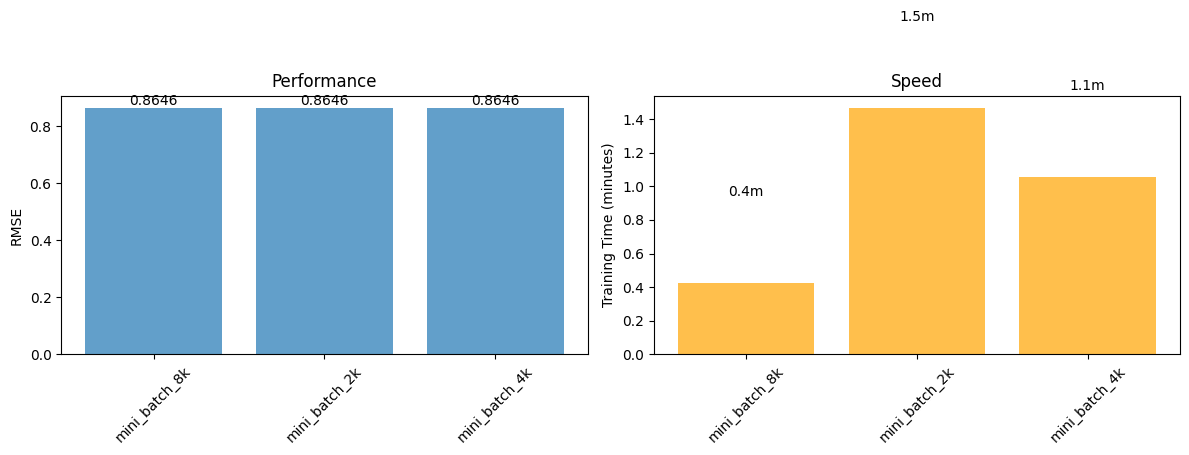


Analysis complete. Best model ready for production.


In [ ]:
# Cell 10: Full 20M Dataset Analysis

def create_gpu_models():
    return {
        'mini_batch_8k': GPUGradientDescent(
            method='mini_batch', learning_rate=0.003, n_iterations=15,
            batch_size=8192, momentum=0.95, regularization='l2', lambda_reg=0.005,
            early_stopping=True, patience=3, verbose=False
        ),
        'mini_batch_4k': GPUGradientDescent(
            method='mini_batch', learning_rate=0.002, n_iterations=20,
            batch_size=4096, momentum=0.9, regularization='l2', lambda_reg=0.01,
            early_stopping=True, patience=5, verbose=False
        ),
        'mini_batch_2k': GPUGradientDescent(
            method='mini_batch', learning_rate=0.0015, n_iterations=25,
            batch_size=2048, momentum=0.9, regularization='l2', lambda_reg=0.01,
            early_stopping=True, patience=7, verbose=False
        )
    }

def train_full_dataset(models, data_splits):
    X_train = data_splits['X_train']
    y_train = data_splits['y_train']
    X_val = data_splits['X_val']
    y_val = data_splits['y_val']
    X_test = data_splits['X_test']
    y_test = data_splits['y_test']

    print(f"Training: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")

    results = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")
        start_time = time.time()

        try:
            model.fit(X_train, y_train, X_val, y_val)
            predictions = model.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)
            mae = mean_absolute_error(y_test, predictions)
            training_time = time.time() - start_time

            results[name] = {
                'rmse': rmse,
                'r2': r2,
                'mae': mae,
                'time': training_time,
                'iterations': len(model.loss_history),
                'samples': len(X_train)
            }

            print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}, Time: {training_time/60:.1f}m")

            if GPU_AVAILABLE:
                mempool = cp.get_default_memory_pool()
                mempool.free_all_blocks()

        except Exception as e:
            print(f"Failed: {e}")
            results[name] = {'error': str(e)}

    return results

def display_full_results(results):
    successful = {k: v for k, v in results.items() if 'error' not in v}

    if not successful:
        print("No successful models")
        return

    print(f"\n{'Model':<15} {'RMSE':<8} {'R²':<8} {'MAE':<8} {'Time(m)':<8} {'Iters':<6}")
    print("-" * 65)

    sorted_results = sorted(successful.items(), key=lambda x: x[1]['rmse'])

    for name, res in sorted_results:
        print(f"{name:<15} {res['rmse']:<8.4f} {res['r2']:<8.4f} {res['mae']:<8.4f} "
              f"{res['time']/60:<8.1f} {res['iterations']:<6}")

    best_name, best_res = sorted_results[0]
    print(f"\nBest: {best_name} (RMSE: {best_res['rmse']:.4f})")

    samples_millions = best_res['samples'] / 1_000_000
    throughput = samples_millions / (best_res['time'] / 60)
    print(f"Throughput: {throughput:.1f}M samples/minute")

    if len(successful) > 1:
        names = [name for name, _ in sorted_results]
        rmse_vals = [res['rmse'] for _, res in sorted_results]
        time_vals = [res['time']/60 for _, res in sorted_results]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        bars1 = ax1.bar(names, rmse_vals, alpha=0.7)
        ax1.set_ylabel('RMSE')
        ax1.set_title('Performance')
        ax1.tick_params(axis='x', rotation=45)
        for bar, val in zip(bars1, rmse_vals):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.4f}', ha='center', va='bottom')

        bars2 = ax2.bar(names, time_vals, alpha=0.7, color='orange')
        ax2.set_ylabel('Training Time (minutes)')
        ax2.set_title('Speed')
        ax2.tick_params(axis='x', rotation=45)
        for bar, val in zip(bars2, time_vals):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}m', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

    return successful

print("Starting full 20M dataset analysis...")

gpu_models = create_gpu_models()
full_results = train_full_dataset(gpu_models, data_splits)
successful_models = display_full_results(full_results)

print(f"\nAnalysis complete. Best model ready for production.")